# Analysis of the 1-Dimensional Random Walk

### One-Dimensional Simple Random Walks

A one-dimensional simple random walk is a discrete-time stochastic process $(S_n)_{n \in \mathbb{N_0}}$ defined by

$$ S_0 = 0, \quad \text{and} \quad S_n = \sum^{n}_{i=1} X_i, \quad \text{for all} \; n \in \mathbb{N},$$

where $X_1, X_2, \dots$ are independent and identically distributed random variables defined by

$$

X_i = 

\begin{cases}
    1 & \text{with probability $p$,} \\
    -1 & \text{with probability $1-p$,} 
\end{cases}

\quad

0 < p < 1.

$$

If $p = \frac{1}{2}$, the process is called a symmetric simple random walk, otherwise it is called a biased simple random walk.

Below are examples of one-dimensional simple random walks (both symmetric and biased) generated through simulation.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


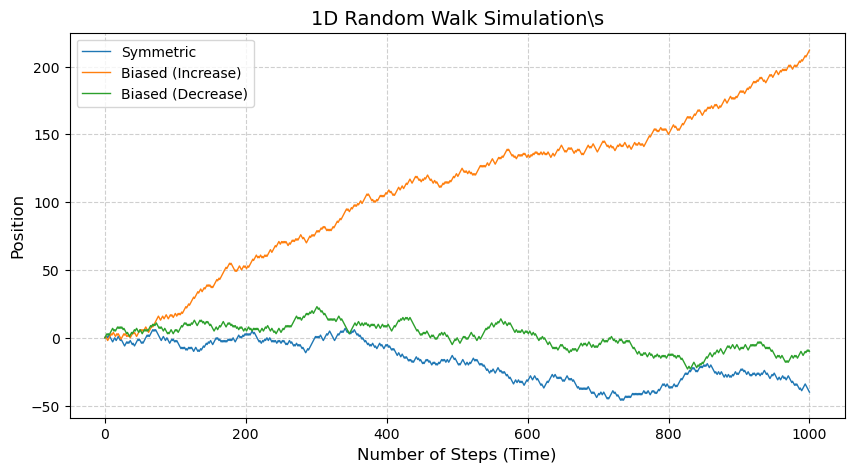

In [37]:
%load_ext autoreload
%autoreload 2

import src.random_walk as rw

_, walk_1_positions = rw.generate_1D_random_walk(1000, [-1, 1], [0.5, 0.5]) # A symmetric simple random walk.
_, walk_2_positions = rw.generate_1D_random_walk(1000, [-1, 1], [0.4, 0.6]) # A biased random walk, that tends to increase in value.
_, walk_3_positions = rw.generate_1D_random_walk(1000, [-1, 1], [0.51, 0.49]) # A biased random walk, that tends to decrease in value extremely slowly.

rw.plot_1D_random_walks([walk_1_positions, walk_2_positions, walk_3_positions], ["Symmetric", "Biased (Increase)", "Biased (Decrease)"])

Now note that

$$\mathbb{E}[X_i] = 1 \cdot p + -1 \cdot (1-p) = 2p - 1.$$

Hence, since $S_n = \sum_{i=1}^{n} X_i$ for all $n \in \mathbb{N}$, it follows that

$$\mathbb{E} [S_n] = \mathbb{E} [\sum_{i=1}^{n} X_i] = \sum_{i=1}^{n} \mathbb{E} [X_i] = n(2p - 1), \quad n \in \mathbb{N}.$$


Furthermore, for all $i = 1, 2, \dots,$

$$\mathbb{E}[X_i^2] = 1^2 \cdot p + (-1)^2 \cdot (1-p) = 1.$$

Therefore

$$ Var(X_i) = \mathbb{E}[X_i^2] - \mathbb{E}[X_i]^2 = 1 - (2p - 1)^2 = 4p(1 - p),$$

and since $X_1, X_2, \dots$ are independent,

$$Var(S_n) = \sum_{i=1}^n Var(X_i) = \sum_{i=1}^n 4p(1 - p) = 4np(1-p), \quad n \in \mathbb{N}.$$

Since $\mathbb{E}[S_n] = 2p-1$ we would expect the average end position of the simple walk to be $2p-1.$ Below we simulate symmetric simple random walks of lenght 10, 100 and 1000 respectively.

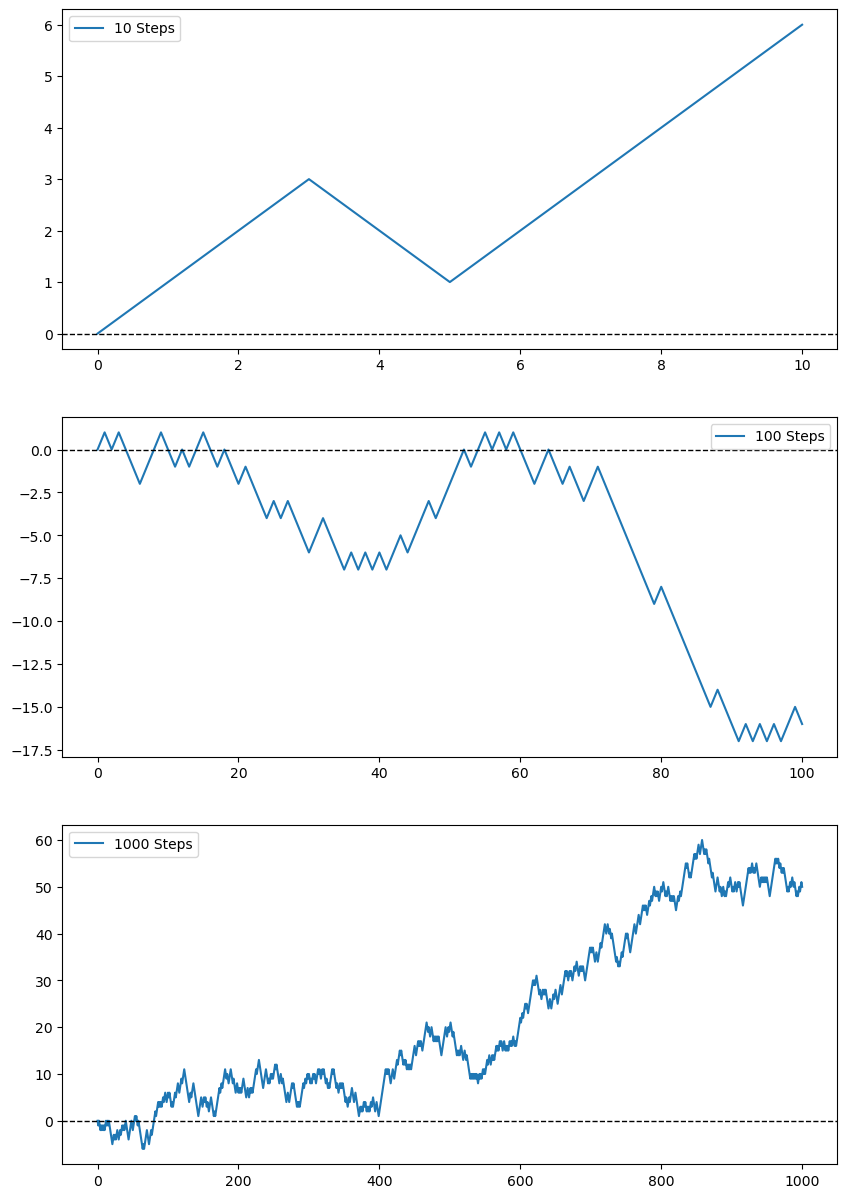

In [118]:
import matplotlib.pyplot as plt
import numpy as np

_, symmetric_walk_10 = rw.generate_1D_random_walk(10, [-1, 1], [0.5, 0.5]) 
_, symmetric_walk_100 = rw.generate_1D_random_walk(100, [-1, 1], [0.5, 0.5])
_, symmetric_walk_1000 = rw.generate_1D_random_walk(1000, [-1, 1], [0.5, 0.5])

walk_10_mean, walk_100_mean, walk_1000_mean = np.mean(symmetric_walk_10), np.mean(symmetric_walk_100), np.mean(symmetric_walk_1000)

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

axs[0].plot(symmetric_walk_10, label="10 Steps")
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=1) 
axs[0].legend()

axs[1].plot(symmetric_walk_100, label="100 Steps")
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].legend()

axs[2].plot(symmetric_walk_1000, label="1000 Steps")
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1) 
axs[2].legend()

plt.show()


The final position of an individual simulated random walk may differ substantially from the theoretical expected value. However, when many independent walks are simulated and their final positions are averaged, this sample mean approaches the theoretical expectation $n(2p -1)$ in accorance with the Law of Large Numbers.

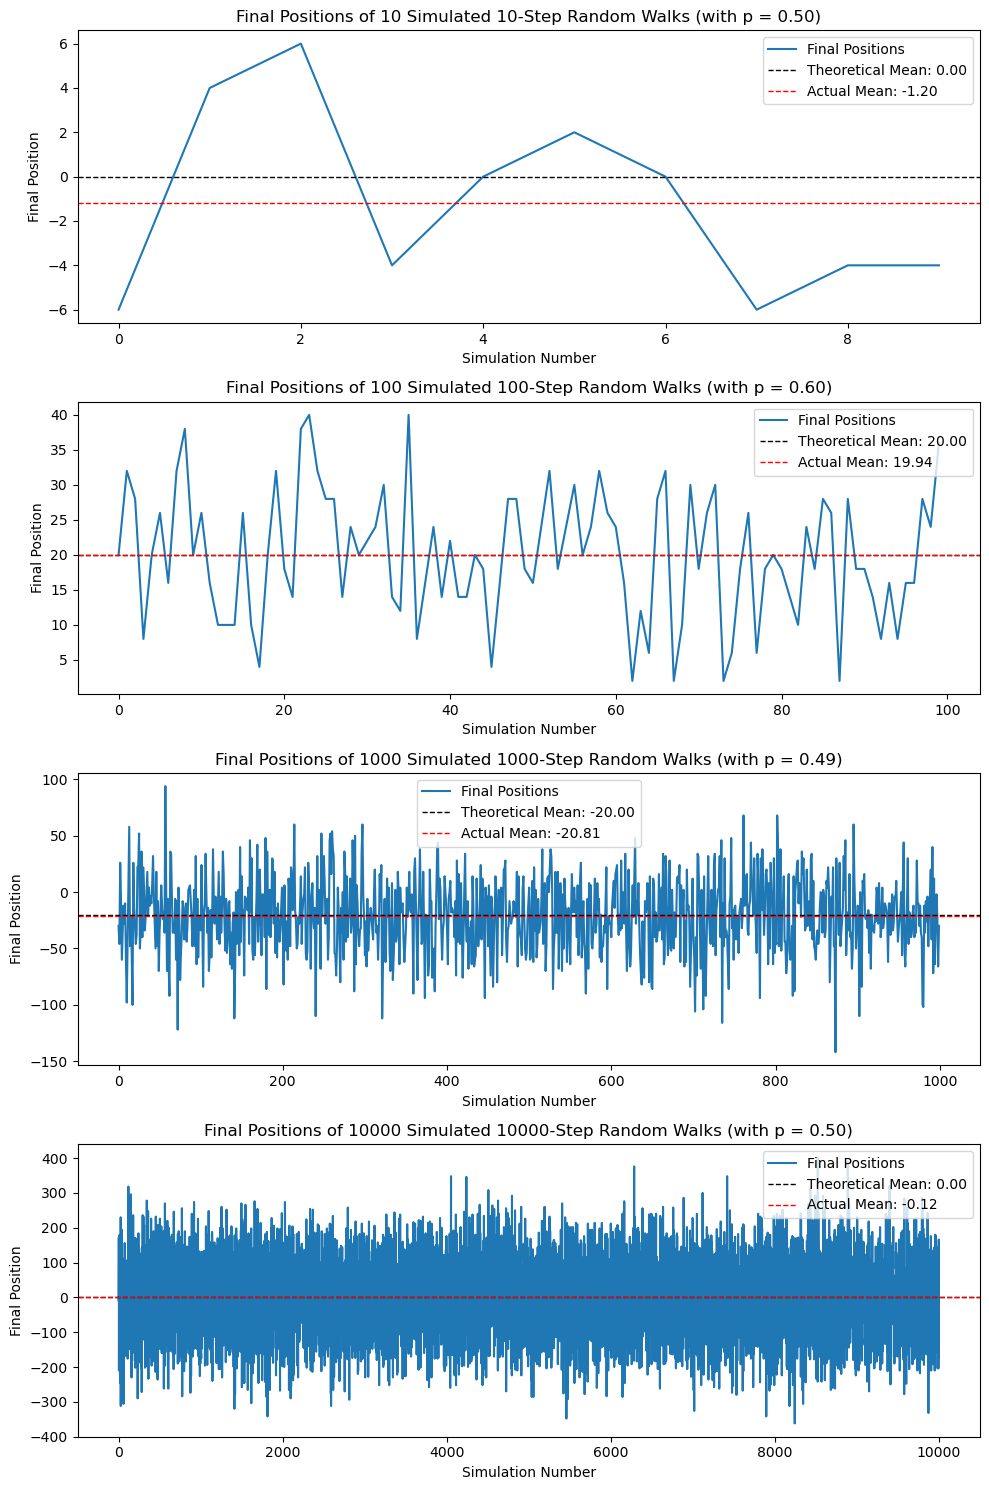

In [115]:
numbers_of_walks = [10, 100, 1000, 10000]
probs = [[0.5, 0.5], [0.4, 0.6], [0.51, 0.49], [0.5, 0.5]]

final_positions = []

for i in range(len(numbers_of_walks)):
    positions = []

    for _ in range(numbers_of_walks[i]):
        _, walk_positions = rw.generate_1D_random_walk(numbers_of_walks[i], [-1, 1], probs[i])

        positions.append(walk_positions[len(walk_positions) - 1])

    final_positions.append(positions)

fig, axs = plt.subplots(len(numbers_of_walks), 1, figsize=(10, 15))

for i in range(len(numbers_of_walks)):
    n = numbers_of_walks[i]
    p = probs[i][1]

    axs[i].plot(final_positions[i], label=f"Final Positions")
    axs[i].axhline(y=n*(2*p-1), color='black', linestyle='--', linewidth=1, label=f"Theoretical Mean: {n*(2*p-1):.2f}")
    axs[i].axhline(y=np.mean(final_positions[i]), color='red', linestyle='--', linewidth=1, label=f"Actual Mean: {np.mean(final_positions[i]):.2f}")

    axs[i].set_title(f"Final Positions of {numbers_of_walks[i]} Simulated {n}-Step Random Walks (with p = {p:.2f})")

    axs[i].set_xlabel("Simulation Number")
    axs[i].set_ylabel("Final Position")

    axs[i].legend()

plt.tight_layout()
plt.show()

As is the case with the means, the final positions of individual simulated random walks may vary considerably, resulting in variance estimates that differ from the theoretical value. However, as the number of independent simulations increases, the sample variance of the final positions approaches the theoretical variance $4np(1-p)$ in again accordance with the Law of Large Numbers.

Another important aspect arises from the Central Limit Theorem(CLT), The CLT implies that the distribution of the final positions of a large number of independent simple random walks becomes approximately normal as the number of steps increases. Tt also implies that the distribution of sample means of the final positions approaches a normal distribution.

Below this is demonstrated using simulations.

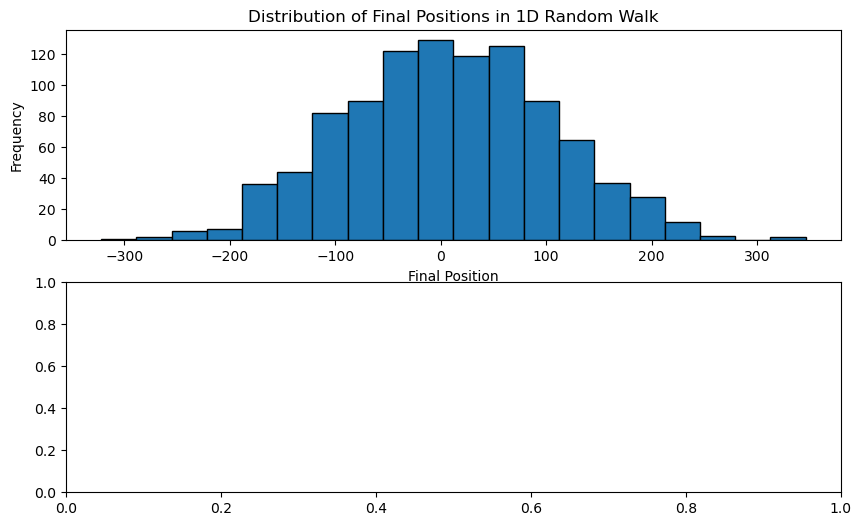

In [ ]:
import src.random_walk as rw
import matplotlib.pyplot as plt
import numpy as np

symmetric_rw = [rw.generate_1D_random_walk(10000, [-1, 1], [0.5, 0.5])[1] for _ in range(1000)]
symmetric_rw_final_positions = [walk[-1] for walk in symmetric_rw]

asymmetric_rw = [rw.generate_1D_random_walk(10000, [-1, 1], [0.4, 0.6])[1] for _ in range(1000)]
asymmetric_rw_final_positions = [walk[-1] for walk in asymmetric_rw]

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].hist(symmetric_rw_final_positions, bins=20, edgecolor='black')
axs[0].set_xlabel('Final Position')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution of Final Positions in Symmetric Simple 1D Random Walk')

axs[1].hist(asymmetric_rw_final_positions, bins=20, edgecolor='black')
axs[1].set_xlabel('Final Position')
axs[1].set_ylabel('Frequency')  
axs[1].set_title('Distribution of Final Positions in Asymmetric Simple 1D Random Walk (p = 0.6)')

plt.show()


